In [39]:
#Cambiar a entorno virtual y cargar paquetes

import numpy as np
import pandas as pd
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth
from pysyncon.utils import PlaceboTest
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

In [40]:
datos = pd.read_csv('../data/dataset_prueba.csv')
datos['date'] = pd.to_datetime(datos['date'])
# Describir serie temporal del movimiento en las provincias españolas 
datos.set_index('date', inplace=True, drop=False)

In [41]:
#Set PANDAS to show all columns in DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [42]:
print ("# of variables in dataframe:", len(datos.columns))

print  ("# of observations in dataframe:", len(datos))

# of variables in dataframe: 41
# of observations in dataframe: 12040


In [43]:
np.round(datos.describe(), 2).T[['count','mean', 'std', 'min', 'max']]

,count,mean,std,min,max
date,12040,2021-06-17 12:00:00.000000256,NaN,2020-02-17 00:00:00,2022-10-17 00:00:00
retail_and_recreation_percent_change_from_baseline,12040.00,-16.44,21.60,-95.60,74.60
grocery_and_pharmacy_percent_change_from_baseline,12040.00,5.12,15.71,-66.20,83.60
parks_percent_change_from_baseline,12040.00,49.68,71.70,-95.80,631.00
transit_stations_percent_change_from_baseline,12040.00,-17.60,24.54,-88.60,123.20
workplaces_raw,12040.00,-25.00,14.68,-87.00,6.60
residential_percent_change_from_baseline,12040.00,7.07,6.02,-3.80,42.60
trend,12040.00,-19.00,9.86,-80.07,12.36
workplaces,12040.00,-18.67,11.80,-76.79,19.06
Valor_Stringency_Index,12040.00,27.49,29.84,0.00,93.52


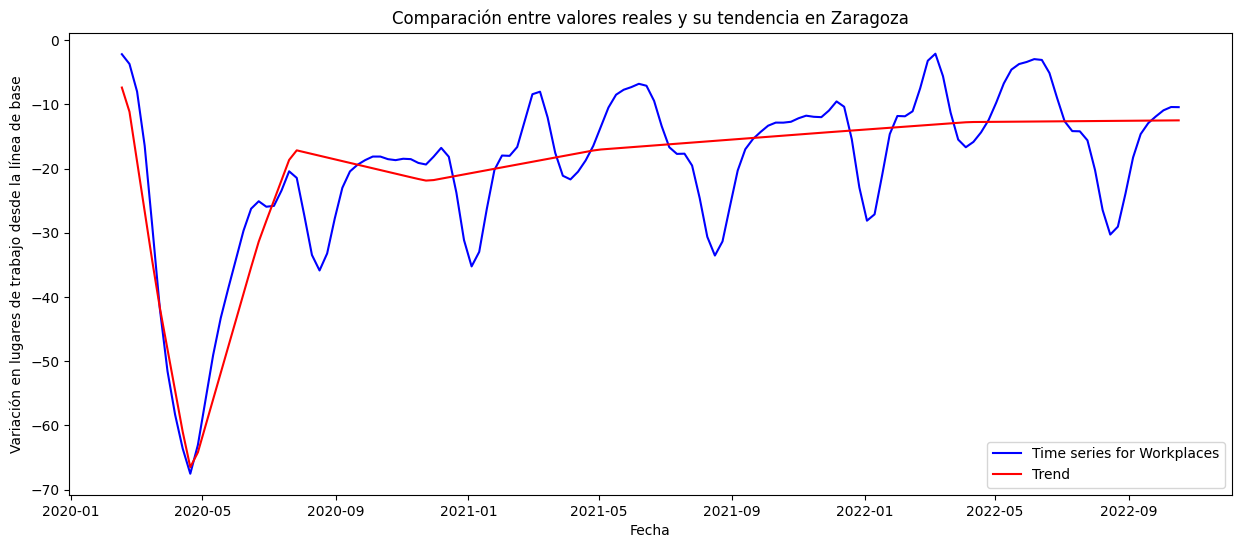

In [44]:
# Filtra los datos solo para la ciudad de 'Zaragoza'
zaragoza_data = datos[datos['NAME'] == 'Zaragoza']

# Configura el tamaño del gráfico
plt.figure(figsize=(15, 6))

# # Grafica la serie temporal 'workplaces_percent_change_from_baseline' para Zaragoza
plt.plot(zaragoza_data['date'], zaragoza_data['workplaces'], label='Time series for Workplaces', color='blue')

# Grafica la serie temporal 'trend' para Zaragoza
plt.plot(zaragoza_data['date'], zaragoza_data['trend'], label='Trend', color='red')

# Configura etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Variación en lugares de trabajo desde la línea de base')
plt.title('Comparación entre valores reales y su tendencia en Zaragoza')
plt.legend()

# Muestra el gráfico
plt.show()


In [45]:
#Comenzamos análisis exxploratorio ))
print(datos[datos.date.duplicated()]['date'].count())
print('Fecha inicio del histórico: ', datos.date.min())
print('Fecha fin del histórico: ', datos.date.max())
print('Número total de semanas: ', datos.date.nunique())

11900
Fecha inicio del histórico:  2020-02-17 00:00:00
Fecha fin del histórico:  2022-10-17 00:00:00
Número total de semanas:  140


In [ ]:
# Configuración de pysyncon con outcome de movilidad y predictores de pre-tratamiento
municipios_control = [municipio for municipio in datos['NAME'].unique() if municipio != "Zaragoza"]

dataprep = Dataprep(
    foo=datos,
    predictors=[
        "Population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "old_age_dependency",
        "young_age_dependency",
        "sex_ratio",
        "unemp",
        "f_unemp",
        "m_unemp",
        "foreigners",
        "edu2",
        "edu3",
    ],
    predictors_op="mean",
    time_predictors_prior=range(1, 127),
    special_predictors=[
        ("workplaces", range(1, 127), "mean"),
        ("workplaces_raw", range(1, 127), "mean"),
        ("trend", range(1, 127), "mean"),
        ("retail_and_recreation_percent_change_from_baseline", range(1, 127), "mean"),
        ("grocery_and_pharmacy_percent_change_from_baseline", range(1, 127), "mean"),
        ("transit_stations_percent_change_from_baseline", range(1, 127), "mean"),
        ("residential_percent_change_from_baseline", range(1, 127), "mean"),
        ("daily_cases", range(1, 127), "mean"),
        ("workplace_closing", range(1, 127), "mean"),
        ("Valor_Stringency_Index", range(1, 127), "mean"),
        ("Valor_GovernmentResponseIndex", range(1, 127), "mean"),
        ("Valor_EconomicSupportIndex", range(1, 127), "mean"),
        ("Valor_Containment_Health_index", range(1, 127), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier='Zaragoza',
    controls_identifier=municipios_control,
    time_optimize_ssr=range(1, 127),
)

In [47]:
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.01)

In [48]:

print(pen.weights())

Berlin                 0.01
Stuttgart              0.01
Freiburg im Breisgau   0.01
Karlsruhe              0.01
Mannheim               0.01
                       ... 
Palermo                0.01
Catania                0.01
Messina                0.01
Stockholm              0.01
Malmö                  0.01
Name: weights, Length: 85, dtype: float64


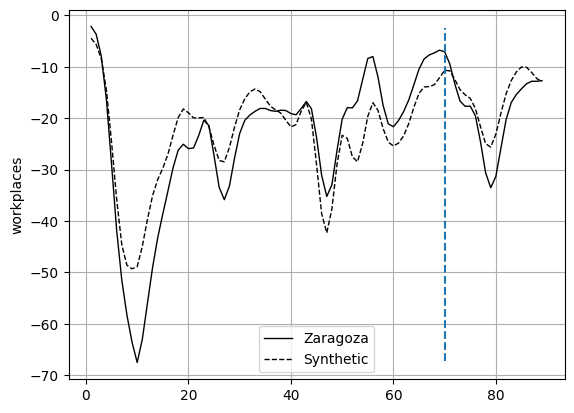

In [ ]:
pen.path_plot(time_period=range(1, 140), treatment_time=127)

In [50]:
pen.summary()

,treated,synthetic,sample mean
Population,679.68,747.51,747.51
agriculture,0.01,0.01,0.01
industry,0.10,0.12,0.12
construction,0.06,0.05,0.05
age_dependency,0.67,0.65,0.65
old_age_dependency,0.32,0.32,0.32
young_age_dependency,0.35,0.33,0.33
sex_ratio,109.07,106.72,106.72
unemp,16.00,12.18,12.18
f_unemp,0.13,0.11,0.11


In [51]:
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

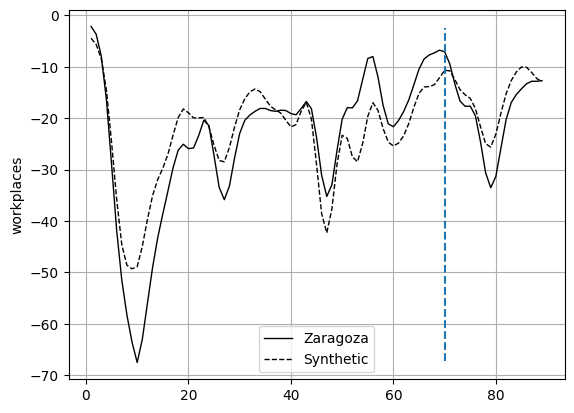

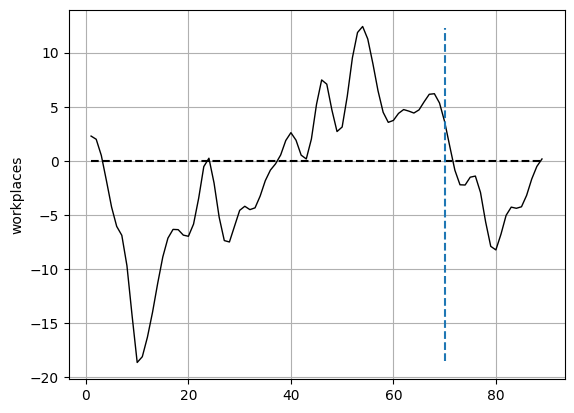

Berlin                 0.01
Stuttgart              0.01
Freiburg im Breisgau   0.01
Karlsruhe              0.01
Mannheim               0.01
                       ... 
Palermo                0.01
Catania                0.01
Messina                0.01
Stockholm              0.01
Malmö                  0.01
Name: weights, Length: 85, dtype: float64

In [ ]:
synth.weights()
synth.path_plot(time_period=range(1, 140), treatment_time=127)
synth.gaps_plot(time_period=range(1, 140), treatment_time=127)
synth.summary()

synth.weights()

In [53]:
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)

In [54]:
print(augsynth.weights())

Berlin                 NaN
Stuttgart              NaN
Freiburg im Breisgau   NaN
Karlsruhe              NaN
Mannheim               NaN
                        ..
Palermo                NaN
Catania                NaN
Messina                NaN
Stockholm              NaN
Malmö                  NaN
Name: weights, Length: 85, dtype: float64


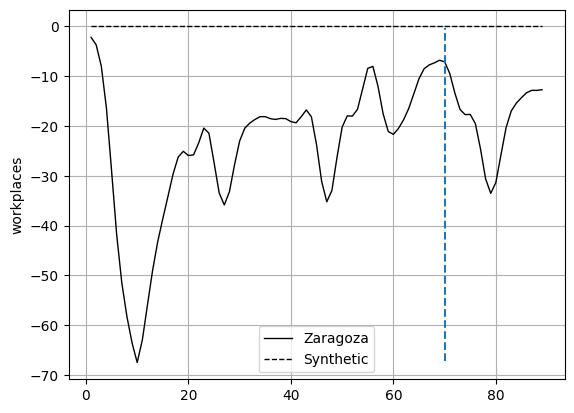

In [ ]:
augsynth.path_plot(time_period=range(1, 140), treatment_time=127)

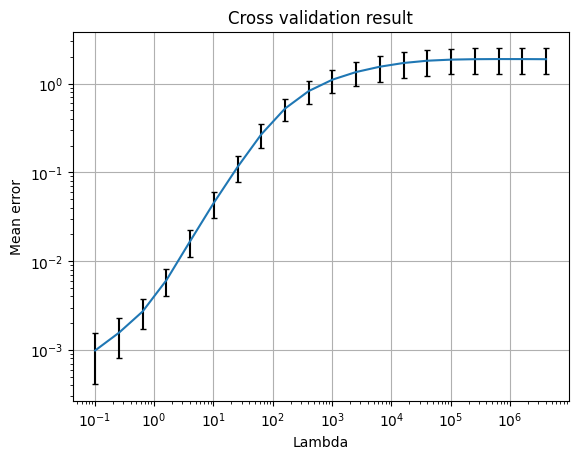

In [56]:
augsynth.cv_result.plot()

In [57]:
augsynth.summary()

,treated,synthetic,sample mean
Population,679.68,0.00,747.51
agriculture,0.01,0.00,0.01
industry,0.10,0.00,0.12
construction,0.06,0.00,0.05
age_dependency,0.67,0.00,0.65
old_age_dependency,0.32,0.00,0.32
young_age_dependency,0.35,0.00,0.33
sex_ratio,109.07,0.00,106.72
unemp,16.00,0.00,12.18
f_unemp,0.13,0.00,0.11
